# Data

The aim of this notebook is to create a dataset of Rice assets.

In this notebook we follow the different steps:
1. Library Importation
2. Data Importation
3. Data Exploration
4. Data Cleaning
5. Data Saving

## 1. Library Importation

In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

## 2. Data Importation

**The Primary Anchor (1 asset)**: 

- rough rice futures (source: Investing.com)

**The Sector Proxies (2–4 assets): Relevant ETFs to capture broader sector beta**
- Invesco DB Agriculture Fund, DBA (yfinance)
- iPath Bloomberg Grains ETN, JJG (yfinance)
- Elements Rogers International Agriculture ETN, RJA (yfinance)
- WisdomTree Grains ETF, 1688.T (yfinance)

**The Individual Universe (10–15 assets): companies
directly involved in the commodity’s value chain**


- KRBL Limited, KRBL.NS (yfinance) – Indian company specializing in basmati rice production and export
- LT Foods Limited, LTFOODS.NS (yfinance) – Indian rice producer and owner of the Daawat basmati brand
- Chaman Lal Setia Exports Ltd, CLSEL.NS (yfinance) – Indian exporter of basmati rice
- Kohinoor Foods Ltd, KOHINOOR.NS (yfinance) – Indian basmati rice producer and exporter
- Archer Daniels Midland Company, ADM (yfinance) – Global agribusiness and grain trading company
- Bunge Global SA, BG (yfinance) – Multinational agribusiness and food company specializing in grain trading
- Olam Group Ltd, VC2.SI (yfinance) – Singapore-based agricultural commodity trader involved in rice and other crops
- Village Farms International Inc, VFF (yfinance) – Agricultural producer focused on controlled-environment farming
- Nutrien Ltd, NTR (yfinance) – Canadian agricultural input company and fertilizer producer supporting global crop production
- Mosaic Company, MOS (yfinance) – Major producer of phosphate and potash fertilizers used in agriculture
- CF Industries Holdings Inc, CF (yfinance) – Global manufacturer of nitrogen fertilizers for crop production
- Adecoagro SA, AGRO (yfinance) – Agricultural production company operating farms and food processing in South America
- Fresh Del Monte Produce Inc, FDP (yfinance) – Global agricultural company involved in food production and distribution


In [19]:
anchor  = pd.read_csv("futures_rice.csv")

sector_proxies = [
    "DBA",         
    "RJA",     
    "1688.T"   
]

companies = [
    "KRBL.NS",
    "LTFOODS.NS",
    "CLSEL.NS",
    "ADM",
    "BG",
    "VC2.SI",
    "VFF",
    "NTR",
    "MOS",
    "CF",
    "AGRO",
    "FDP"
]

In [20]:
tickers = sector_proxies + companies


data = yf.download(tickers, start="2018-01-01", progress=False)

close_prices = data["Close"]

print(close_prices.head())

Ticker      1688.T        ADM      AGRO         BG         CF  CLSEL.NS  \
Date                                                                      
2018-01-01   395.0        NaN       NaN        NaN        NaN       NaN   
2018-01-02   395.0  31.407629  9.198833  52.966419  35.073055       NaN   
2018-01-03   395.0  31.164759  9.394551  54.103806  35.081188       NaN   
2018-01-04   399.0  31.689659  9.350070  54.898441  35.447029       NaN   
2018-01-05   390.0  31.478132  9.207728  54.485542  35.503941       NaN   

Ticker            DBA        FDP     KRBL.NS  LTFOODS.NS        MOS  \
Date                                                                  
2018-01-01        NaN        NaN  556.974426         NaN        NaN   
2018-01-02  16.306484  39.298065  555.493835         NaN  23.238758   
2018-01-03  16.297888  39.524158  560.167603         NaN  23.029480   
2018-01-04  16.272102  40.353153  566.276001         NaN  23.386999   
2018-01-05  16.186140  40.361526  577.104492    

In [21]:
anchor["Date"] = pd.to_datetime(anchor["Date"], dayfirst=True)
anchor["Dernier"] = anchor["Dernier"].str.replace(",", ".").astype(float)
anchor = anchor.set_index("Date")

anchor_close = anchor["Dernier"].rename("Futures")

close_prices = close_prices.join(anchor_close)

df_raw = close_prices.copy()

## 3. Data Exploration

This step aims to give a clear overview of the raw data. This overview will be particularly useful to understand the data and prepare the cleaning part.

In [22]:
def plot_missing_proportions(
    df: pd.DataFrame,
    title: str = "Missing value proportion by asset"
) -> pd.Series:
    """
    Plot the proportion of missing values for each column in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    title : str
        Plot title.

    Returns
    -------
    pd.Series
        Missing value proportions by column.
    """
    if df.empty:
        raise ValueError("The input DataFrame is empty.")

    missing_prop = df.isna().mean().sort_values(ascending=False)

    ax = missing_prop.plot(kind="bar", figsize=(12, 6))
    ax.set_title(title)
    ax.set_xlabel("Assets")
    ax.set_ylabel("Missing value proportion")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.3)

    for i, value in enumerate(missing_prop):
        ax.text(i, value + 0.02, f"{value:.1%}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return missing_prop

def price_visualization(df: pd.DataFrame, title: str = "Asset price trends") -> None:
    # Normalize all prices to 100 at the start of the period for comparison.
    first_valid = df.apply(lambda col: col[col.notna()].iloc[0])
    df_norm = df / first_valid * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # --- Plot 1: Raw prices ---
    for col in df.columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1.2)
    axes[0].set_title('Raw Prices (2020–2026)', fontsize=13)
    axes[0].set_ylabel('Price (USD or local currency)')
    axes[0].legend(fontsize=9)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # --- Plot 2: Normalized prices (rebased to 100) ---
    for col in df_norm.columns:
        axes[1].plot(df_norm.index, df_norm[col], label=col, linewidth=1.2)
    axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].set_title('Normalized Prices (rebased to 100 at start)', fontsize=13)
    axes[1].set_ylabel('Index (base = 100)')
    axes[1].legend(fontsize=9)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [23]:
df_raw

,1688.T,ADM,AGRO,BG,CF,CLSEL.NS,DBA,FDP,KRBL.NS,LTFOODS.NS,MOS,NTR,RJA,VC2.SI,VFF,Futures
Date,,,,,,,,,,,,,,,,
2018-01-01,395.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,556.974426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,395.000000,31.407629,9.198833,52.966419,35.073055,NaN,16.306484,39.298065,555.493835,NaN,23.238758,41.927879,6.06,1.330320,NaN,NaN
2018-01-03,395.000000,31.164759,9.394551,54.103806,35.081188,NaN,16.297888,39.524158,560.167603,NaN,23.029480,42.395023,6.08,1.310757,NaN,NaN
2018-01-04,399.000000,31.689659,9.350070,54.898441,35.447029,NaN,16.272102,40.353153,566.276001,NaN,23.386999,42.540531,6.08,1.330320,NaN,NaN
2018-01-05,390.000000,31.478132,9.207728,54.485542,35.503941,NaN,16.186140,40.361526,577.104492,NaN,23.421879,42.678371,6.04,1.330320,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-17,591.000000,72.120003,12.450000,125.959999,123.290001,234.800003,26.620001,41.369999,283.649994,389.600006,28.830000,79.550003,NaN,0.875000,2.7300,NaN
2026-03-18,557.900024,70.870003,13.630000,124.029999,126.730003,241.100006,26.910000,40.869999,291.700012,394.700012,27.780001,77.879997,NaN,0.880000,2.7300,NaN
2026-03-19,575.900024,68.639999,14.610000,122.040001,125.559998,232.699997,26.969999,40.400002,278.950012,383.200012,26.200001,76.050003,NaN,0.865000,2.6800,NaN


In [24]:
print(f"Dataset shape: {df_raw.shape}  ({df_raw.shape[0]} trading days, {df_raw.shape[1]} assets)")
print(f"Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print()
print("Columns (assets):")
print(list(df_raw.columns))

Dataset shape: (2149, 16)  (2149 trading days, 16 assets)
Date range: 2018-01-01 → 2026-03-23

Columns (assets):
['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'CLSEL.NS', 'DBA', 'FDP', 'KRBL.NS', 'LTFOODS.NS', 'MOS', 'NTR', 'RJA', 'VC2.SI', 'VFF', 'Futures']


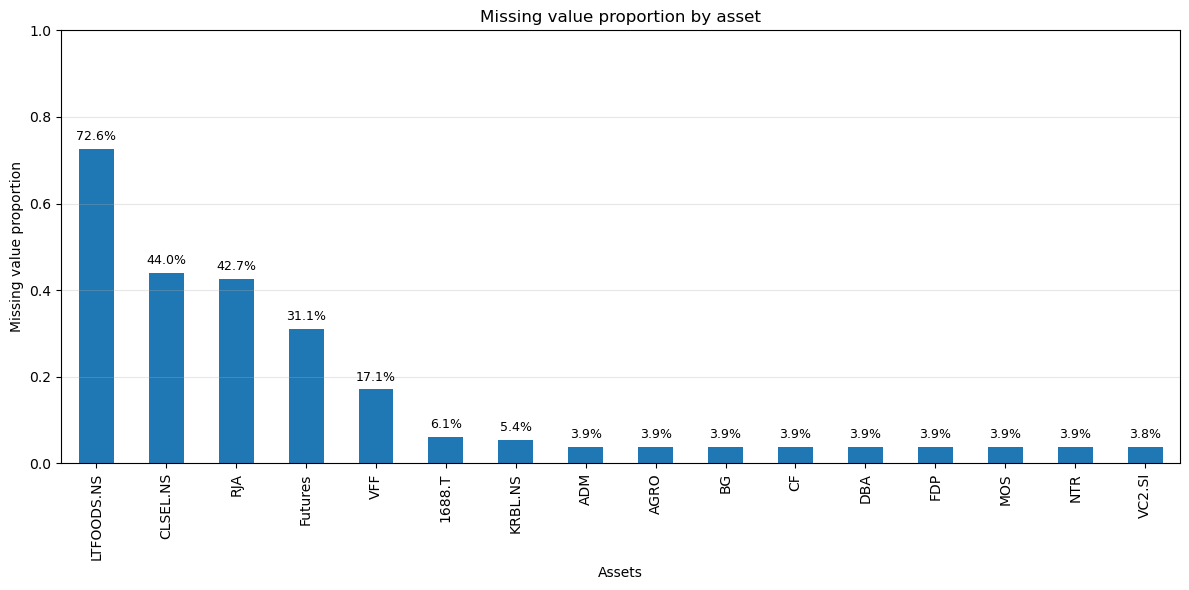

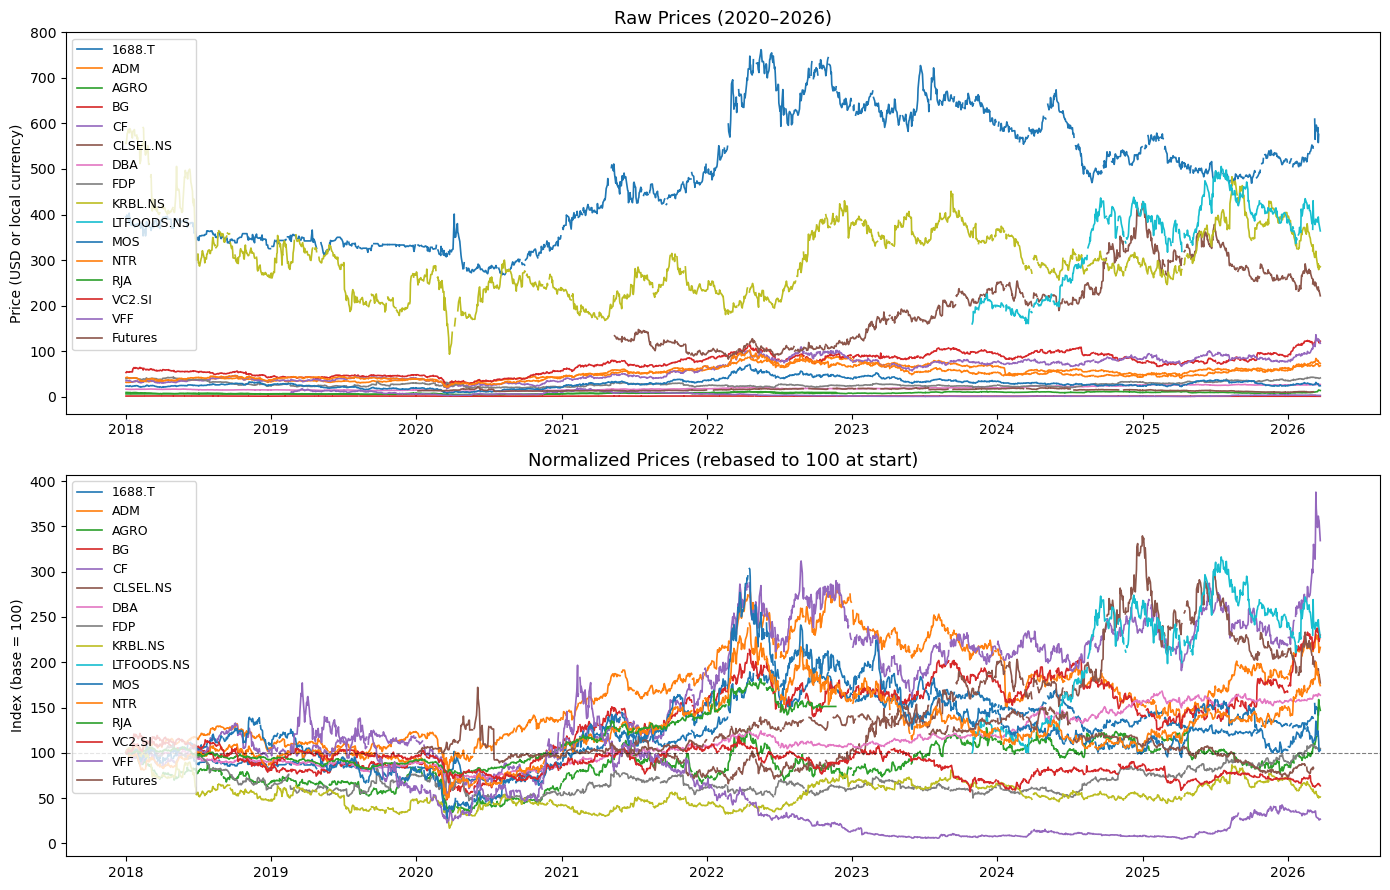

In [25]:
plot_missing_proportions(df_raw)
price_visualization(df_raw)

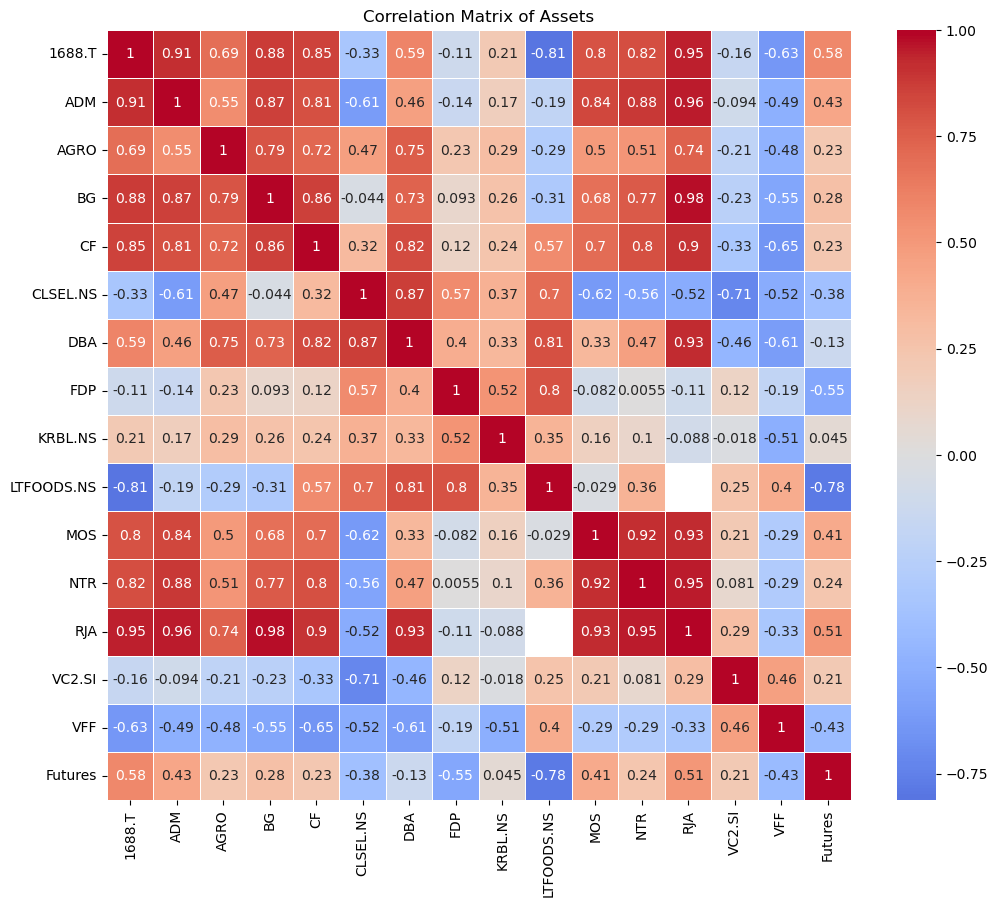

In [26]:
corr_matrix = close_prices.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Assets")
plt.show()

# 4. Data Cleaning

In [27]:
# ==========================
# GLOBAL VARIABLES
# ==========================

START = '2020-01-01'

### 4.1 Keep rows where the Futures is available

`Futures` variable contains NaN values up until 2020. Thus we will start our dataset from this date. Having values up to 2026. We still keep more than 5 years of data in our dataset. 

In [28]:
# ==========================
# DATA CLEANING
# ==========================

ANCHOR = 'Futures'
df = df_raw[df_raw[ANCHOR].notna()].copy()
df = df[df.index >= START]

print(f"After anchor filter — shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print()

After anchor filter — shape: (1481, 16)
Date range: 2020-01-06 → 2026-03-06



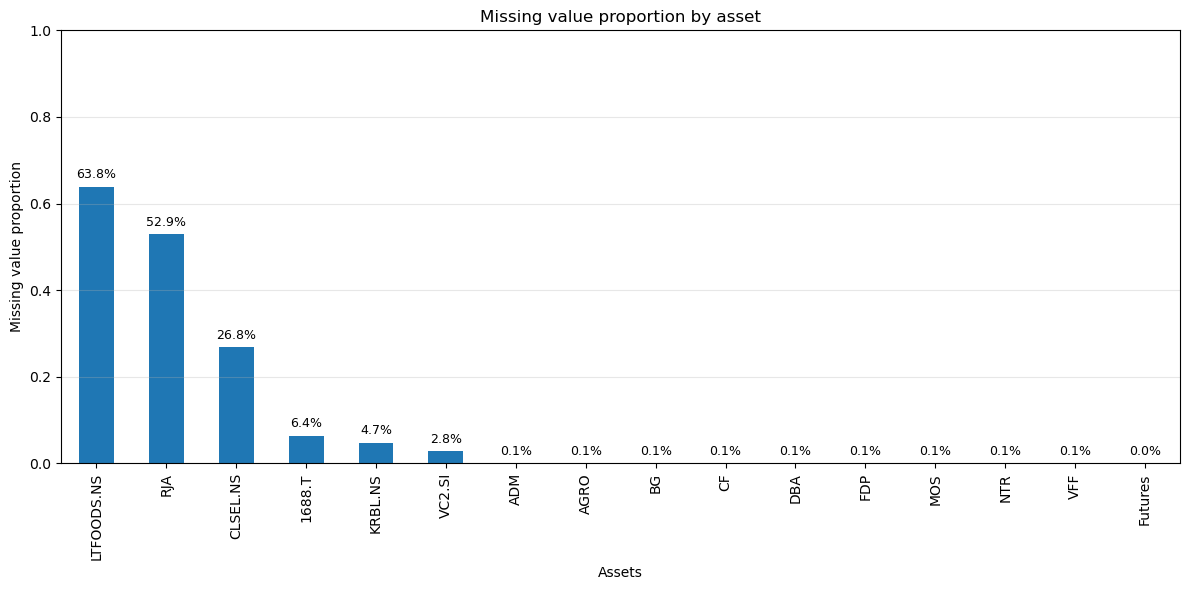

LTFOODS.NS    0.638082
RJA           0.528697
CLSEL.NS      0.268062
1688.T        0.064146
KRBL.NS       0.047265
VC2.SI        0.028359
ADM           0.000675
AGRO          0.000675
BG            0.000675
CF            0.000675
DBA           0.000675
FDP           0.000675
MOS           0.000675
NTR           0.000675
VFF           0.000675
Futures       0.000000
dtype: float64

In [29]:
plot_missing_proportions(df)

### 4.2 Drop assets with more than 20% missing values

In [30]:
MISSING_THRESHOLD = 0.20
missing_pct = df.isnull().mean()
print("Missing value rate per asset:")
print(missing_pct.round(4).to_frame('Missing %').to_string())
print()

assets_to_keep = missing_pct[missing_pct <= MISSING_THRESHOLD].index.tolist()
assets_dropped = missing_pct[missing_pct >  MISSING_THRESHOLD].index.tolist()

print(f"Assets dropped (>{MISSING_THRESHOLD*100:.0f}% missing): {assets_dropped}")
print(f"Assets retained for screening: {assets_to_keep}")
print()

df = df[assets_to_keep].copy()

Missing value rate per asset:
            Missing %
1688.T         0.0641
ADM            0.0007
AGRO           0.0007
BG             0.0007
CF             0.0007
CLSEL.NS       0.2681
DBA            0.0007
FDP            0.0007
KRBL.NS        0.0473
LTFOODS.NS     0.6381
MOS            0.0007
NTR            0.0007
RJA            0.5287
VC2.SI         0.0284
VFF            0.0007
Futures        0.0000

Assets dropped (>20% missing): ['CLSEL.NS', 'LTFOODS.NS', 'RJA']
Assets retained for screening: ['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'DBA', 'FDP', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'Futures']



### 4.3 Forward-fill remaining NaNs

In [31]:
# Step 3: Forward-fill remaining NaNs (align trading days across markets)
# then drop any residual NaN rows
df = df.ffill().dropna()

# Make sure the anchor is still present
assert ANCHOR in df.columns, f"ERROR: Anchor '{ANCHOR}' was dropped — lower MISSING_THRESHOLD."

ALL_ASSETS = list(df.columns)   # full universe passed to screening

print(f"All selected assets for Section 3 screening: {ALL_ASSETS}")

All selected assets for Section 3 screening: ['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'DBA', 'FDP', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF', 'Futures']


### 4.4 Outliers

### 4.5 Price visualization

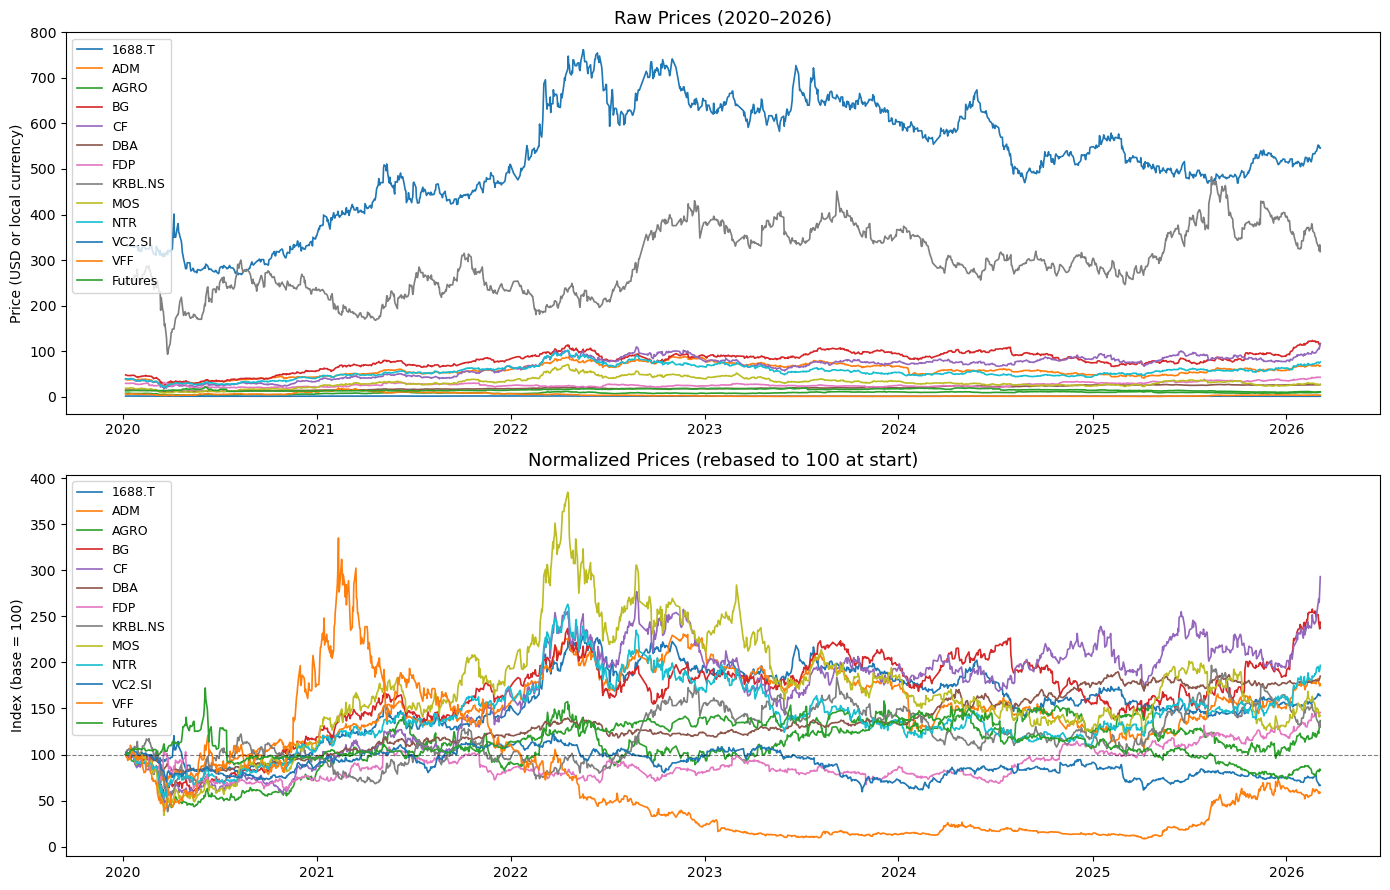

In [32]:
price_visualization(df)

# 5. Data Saving

In [33]:
df.to_csv("data.csv")